# convert GCM output (nc) to tensor, skip spin-up and preprocessing

In [1]:
exp_name = 'gmd_radiative_convective_1420w_10min_v3' #'gmd_radiative_convective_1420w_10min' '64x32_4h_400w'
exp_folder_name = 'column_code_with_slab' # 'column_code_with_slab' 'gmd_aquaplanet' 'column_rrtmg' 'aquaplanet_RCE_single'
nc_data_path = f"/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}"
emulate = 'conv' #'rad' #'conv'
emulate_layer = 28 # N of emulated layers ONLY for convection
skipped_samples = 600000 # 10000 for gmd_aquaplanet #210000 for gmd_radiative_convective_1420w_10min
flatten = False # flatten from [B,C,H,W] to [BHW, C], False for single-column
subsample = False # if subsample
n = 6 # if subsample, n=6. 4h*6=1day, 10min*6=1h

import xarray as xr
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import sys
import os
sys.path.append("..")

# Remove lat/lon dimensions if one-column, else open it normally
if exp_folder_name != 'gmd_aquaplanet':
    ds_input = xr.open_dataset(nc_data_path + '_input.nc').squeeze(['lat', 'lon'])
    ds_output = xr.open_dataset(nc_data_path + '_output.nc').squeeze(['lat', 'lon'])
    # keep='first' keeps the first occurrence and marks later duplicates as True
    dup_mask = ds_input.get_index("time").duplicated(keep="first")
    ds_input = ds_input.isel(time=~dup_mask)
    dup_mask = ds_output.get_index("time").duplicated(keep="first")
    ds_output = ds_output.isel(time=~dup_mask)
    if len(ds_input.time) < len(ds_output.time):
        ds_output = ds_output.isel(time=slice(None, len(ds_input.time)))
    if len(ds_input.time) > len(ds_output.time):
        ds_input = ds_input.isel(time=slice(None, len(ds_output.time)))
    print((ds_output.time == ds_input.time).any().values)
else:
    ds = xr.open_dataset(nc_data_path)

# input and output lists
if exp_folder_name == 'gmd_aquaplanet':
    input_list = ['air_temperature', 'specific_humidity', 'surface_air_pressure',
              'surface_upward_latent_heat_flux', 'surface_upward_sensible_heat_flux']
    if emulate == 'conv':
        output_list = ['air_temperature_tendency_from_EmanuelConvection','specific_humidity_tendency_from_EmanuelConvection',
                  'convective_precipitation_rate']
    if emulate == 'rad':
        output_list = ['air_temperature_tendency_from_longwave']

if exp_folder_name == 'column_code_with_slab':
    input_list = ['air_temperature', 'specific_humidity',
                  'surface_upward_latent_heat_flux', 'surface_upward_sensible_heat_flux','cloud_base_mass_flux']
    if emulate == 'conv':
        output_list = ['air_temperature_tendency_from_EmanuelConvection','specific_humidity_tendency_from_EmanuelConvection',
                  'convective_precipitation_rate']
    if emulate == 'rad':
        output_list = ['air_temperature_tendency_from_longwave']


X_list = []
for i in range(len(input_list)):
    X_list.append(torch.tensor(ds_input[input_list[i]].isel(time=slice(skipped_samples,None)).values, dtype=torch.float32))
if exp_folder_name != 'gmd_aquaplanet':
    X = torch.cat([x.reshape(x.shape[0], -1) for x in X_list], dim=1)
else:
    for i in range(len(X_list)):
        # for scalar vars [B,H,W]
        if X_list[i].ndim==3:
            X_list[i] = X_list[i].unsqueeze(1)
    X = torch.cat([x for x in X_list], dim=1)
y_list = []
for i in range(len(output_list)):
    y_list.append(torch.tensor(ds_output[output_list[i]].isel(time=slice(skipped_samples,None)).values, dtype=torch.float32))
if exp_folder_name != 'gmd_aquaplanet':
    y = torch.cat([y.reshape(y.shape[0], -1) for y in y_list], dim=1)
else:
    for i in range(len(y_list)):
        # for output vars [B,H,W,C], do nothing if aleady [B,C,H,W]
        if y_list[i].ndim==4 and list(y_list[i].shape)[1:]==[32,64,28]:
            y_list[i] = y_list[i].permute(0,3,1,2) # [B,C,H,W]
        # for scalar vars [B,H,W]
        if y_list[i].ndim==3:
            y_list[i] = y_list[i].unsqueeze(1) # [B,1,H,W]
        # print(y_list[i].shape)
    y = torch.cat([y for y in y_list], dim=1)
    

# if further subsample: e.g., 4h->day
if subsample == True:
    X = X[::n]  # take every n-th sample along dim 0
    y = y[::n]

# Split into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
# Split train into train (60%) and val (20%)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, shuffle=False)
print(X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape)

# if flatten
if flatten == True:
    X_train = X_train.permute(0, 2, 3, 1).reshape(-1, X_train.shape[1])
    X_val = X_val.permute(0, 2, 3, 1).reshape(-1, X_val.shape[1])
    X_test = X_test.permute(0, 2, 3, 1).reshape(-1, X_test.shape[1])
    y_train = y_train.permute(0, 2, 3, 1).reshape(-1, y_train.shape[1])
    y_val = y_val.permute(0, 2, 3, 1).reshape(-1, y_val.shape[1])
    y_test = y_test.permute(0, 2, 3, 1).reshape(-1, y_test.shape[1])

# only emulate top N layers for convection, diable top 28-N layers
if emulate == 'conv':
    idx_X = list(range(0, emulate_layer)) + list(range(28, 28+emulate_layer)) + list(range(56, X_train.shape[-1]))
    idx_y = list(range(0, emulate_layer)) + list(range(28, 28+emulate_layer)) + [y_train.shape[-1]-1]
    X_train = X_train[..., idx_X]
    X_val   = X_val[..., idx_X]
    X_test  = X_test[..., idx_X]
    y_train = y_train[..., idx_y]
    y_val   = y_val[..., idx_y]
    y_test  = y_test[..., idx_y]

# normalization
X_mean = X_train.mean(dim=0)   # shape [C] for all T,H,W
X_std  = X_train.std(dim=0)
X_max  = X_train.max(dim=0).values
X_min  = X_train.min(dim=0).values
y_mean = y_train.mean(dim=0)   # shape [C] for all T,H,W
y_std  = y_train.std(dim=0)
y_max  = y_train.max(dim=0).values
y_min  = y_train.min(dim=0).values
print('After Flatten:', X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape)

# save data
os.makedirs(f"/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}_{emulate}", exist_ok=True)
torch.save(X_train, f"/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}_{emulate}/X_train.pth")
torch.save(X_val, f"/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}_{emulate}/X_val.pth")
torch.save(X_test, f"/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}_{emulate}/X_test.pth")
torch.save(y_train, f"/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}_{emulate}/y_train.pth")
torch.save(y_val, f"/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}_{emulate}/y_val.pth")
torch.save(y_test, f"/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}_{emulate}/y_test.pth")
# save normalization files
torch.save({
    'X_mean': X_mean,
    'X_std': X_std,
    'X_max': X_max,
    'X_min': X_min,
    'y_mean': y_mean,
    'y_std': y_std,
    'y_max': y_max,
    'y_min': y_min
}, f"/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}_{emulate}/normalization.pth")

True
torch.Size([239588, 59]) torch.Size([79863, 59]) torch.Size([79863, 59]) torch.Size([239588, 57]) torch.Size([79863, 57]) torch.Size([79863, 57])
After Flatten: torch.Size([239588, 59]) torch.Size([79863, 59]) torch.Size([79863, 59]) torch.Size([239588, 57]) torch.Size([79863, 57]) torch.Size([79863, 57])


# visulization

In [1]:
import xarray as xr
exp_name = 'gmd_radiative_convective_1420w_10min_v3' #'64x32_4h_400w' 'gmd_radiative_convective_1420w_10min'
exp_folder_name = 'column_code_with_slab' # 'column_code_with_slab' 'gmd_aquaplanet'
nc_data_path = f"/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}"
a=xr.open_dataset(nc_data_path + '_input.nc')
a

<xarray.Dataset>
Dimensions:                            (time: 1030384, interface_levels: 29,
                                        lat: 1, lon: 1, mid_levels: 28)
Coordinates:
  * time                               (time) datetime64[ns] 2000-01-01 ... 2...
Dimensions without coordinates: interface_levels, lat, lon, mid_levels
Data variables: (12/14)
    downwelling_shortwave_flux_in_air  (time, interface_levels, lat, lon) float64 ...
    air_pressure_on_interface_levels   (time, interface_levels, lat, lon) float64 ...
    eastward_wind                      (time, mid_levels, lat, lon) float64 ...
    surface_air_pressure               (time, lat, lon) float64 ...
    upwelling_longwave_flux_in_air     (time, interface_levels, lat, lon) float64 ...
    air_temperature                    (time, mid_levels, lat, lon) float64 ...
    ...                                 ...
    surface_upward_sensible_heat_flux  (time, lat, lon) float64 ...
    upwelling_shortwave_flux_in_air    (time, interface_levels, lat, lon) float64 ...
    downwelling_longwave_flux_in_air   (time, interface_levels, lat, lon) float64 ...
    air_pressure                       (time, mid_levels, lat, lon) float64 ...
    cloud_base_mass_flux               (time, lat, lon) float64 ...
    specific_humidity                  (time, mid_levels, lat, lon) float64 ...

In [3]:
a['air_pressure'][10000].values

array([[[101044.31028195]],

       [[100195.77632998]],

       [[ 98759.75807376]],

       [[ 96753.28367666]],

       [[ 94200.14571469]],

       [[ 91130.61904626]],

       [[ 87581.10181559]],

       [[ 83593.68384656]],

       [[ 79215.64754524]],

       [[ 74498.90722888]],

       [[ 69499.39352997]],

       [[ 64276.39017481]],

       [[ 58891.83100071]],

       [[ 53409.56554756]],

       [[ 47894.6019316 ]],

       [[ 42412.33597849]],

       [[ 37027.77575477]],

       [[ 31804.77068994]],

       [[ 26805.25442421]],

       [[ 22088.51034726]],

       [[ 17710.4685095 ]],

       [[ 13723.04217571]],

       [[ 10173.51171009]],

       [[  7103.96255531]],

       [[  4550.78198329]],

       [[  2544.21105313]],

       [[  1107.88404987]],

       [[   256.0893821 ]]])

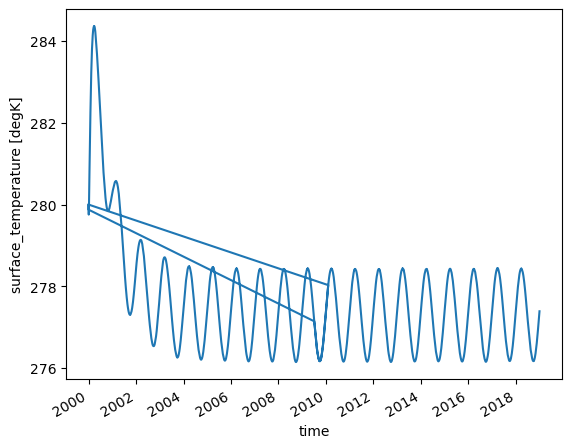

In [4]:
# single
import xarray as xr
exp_name = 'gmd_radiative_convective_1420w_10min_v3' #'64x32_4h_400w' 'gmd_radiative_convective_1420w_10min'
exp_folder_name = 'column_code_with_slab' # 'column_code_with_slab' 'gmd_aquaplanet'
nc_data_path = f"/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}"
a=xr.open_dataset(nc_data_path + '_input.nc')
a['surface_temperature'][:].plot()

In [1]:
import xarray as xr
import numpy as np
a=xr.open_dataset('/projects/sds-lab/Shuochen/climt/gmd_aquaplanet/64x32_4h_400w_v3_input.nc')
# a['air_temperature'].isel(lat=15,lon=32,mid_levels=0).plot()

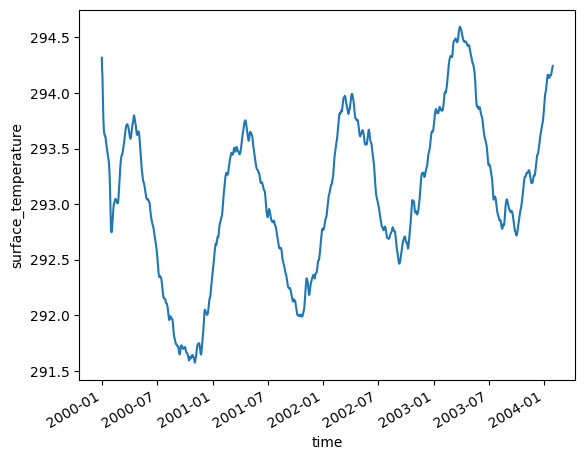

In [2]:
a['surface_temperature'].mean(dim=('lat', 'lon')).plot()

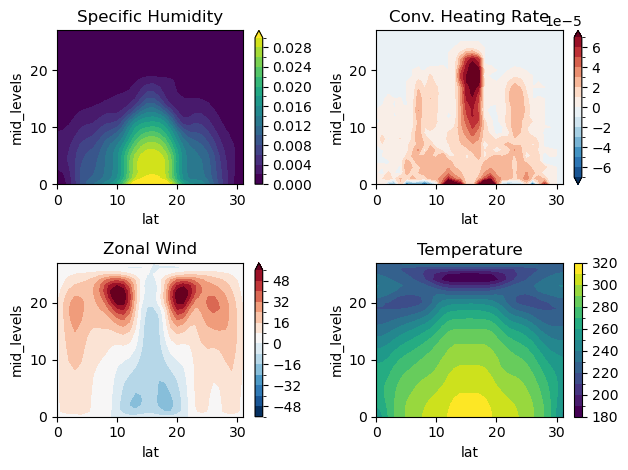

In [6]:
exp_name = '64x32_4h_400w_v2' # '64x32_4h_400w' '64x32_4h_350_new'
exp_folder_name = 'gmd_aquaplanet' # 'column_code_with_slab' 'gmd_aquaplanet' 'column_rrtmg' 'aquaplanet_RCE_single'

import os,pickle,matplotlib.pyplot as plt

def plot_function(fig, state):

    ax = fig.add_subplot(2, 2, 1)
    state['specific_humidity'].mean(
        dim='lon').plot.contourf(
            ax=ax, levels=16, robust=True)
    ax.set_title('Specific Humidity')

    ax = fig.add_subplot(2, 2, 3)
    state['eastward_wind'].mean(dim='lon').plot.contourf(
        ax=ax, levels=16, robust=True)
    ax.set_title('Zonal Wind')

    ax = fig.add_subplot(2, 2, 2)
    state['air_temperature_tendency_from_EmanuelConvection'].transpose().mean(
        dim='lon').plot.contourf(
        ax=ax, levels=16, robust=True)
    ax.set_title('Conv. Heating Rate')

    ax = fig.add_subplot(2, 2, 4)
    state['air_temperature'].mean(dim='lon').plot.contourf(
        ax=ax, levels=16)
    ax.set_title('Temperature')
    fig.tight_layout()
 
checkpoint_path = f'/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}_checkpoints/latest.pkl'
if os.path.exists(checkpoint_path):
    with open(checkpoint_path, "rb") as f:
        data = pickle.load(f)
    my_state, start_i = data["state"], data["i"]
plot_function(plt.figure(),my_state)

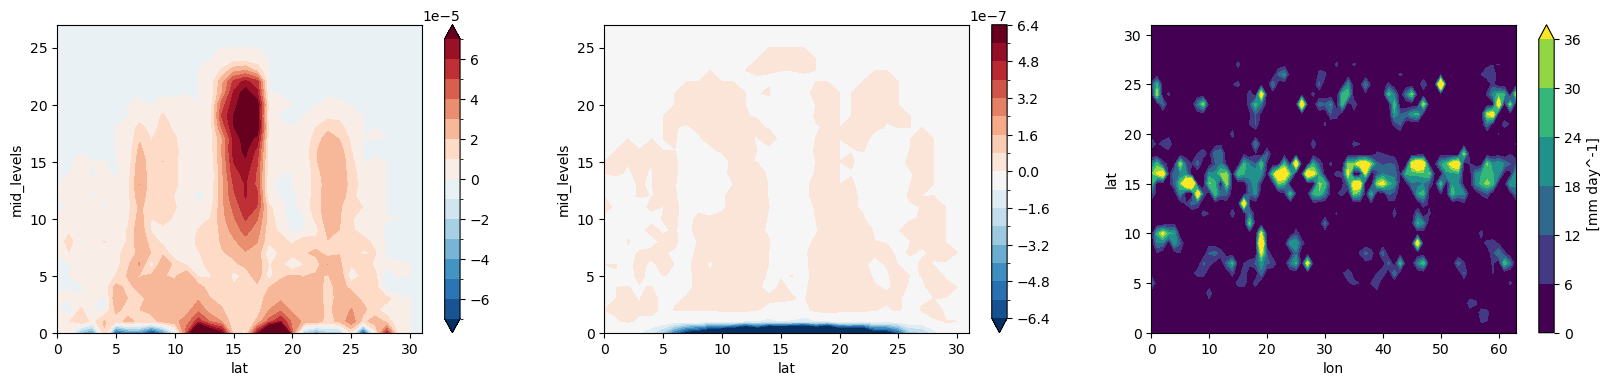

In [7]:
fig = plt.figure(figsize=(20,4))
ax = fig.add_subplot(1, 3, 1)
my_state['air_temperature_tendency_from_EmanuelConvection'].transpose().mean(dim='lon').plot.contourf(ax=ax, levels=16, robust=True)
ax2 = fig.add_subplot(1, 3, 2)
my_state['specific_humidity_tendency_from_EmanuelConvection'].transpose().mean(dim='lon').plot.contourf(ax=ax2, levels=16, robust=True)
ax3 = fig.add_subplot(1, 3, 3)
my_state['convective_precipitation_rate'].plot.contourf(ax=ax3, robust=True)

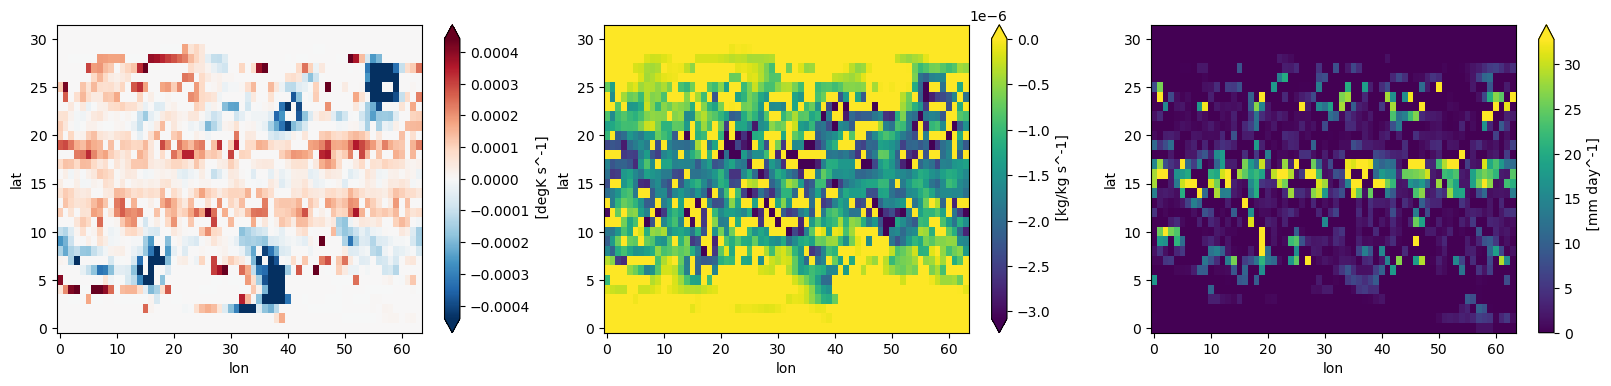

In [8]:
fig = plt.figure(figsize=(20,4))
ax = fig.add_subplot(1, 3, 1)
my_state['air_temperature_tendency_from_EmanuelConvection'].isel(mid_levels=0).plot(ax=ax, robust=True)
ax = fig.add_subplot(1, 3, 2)
my_state['specific_humidity_tendency_from_EmanuelConvection'].isel(mid_levels=0).plot(ax=ax, robust=True)
ax = fig.add_subplot(1, 3, 3)
my_state['convective_precipitation_rate'].plot(ax=ax, robust=True)